In [351]:
%reload_ext autoreload
%autoreload 2

In [352]:

import blackjax

from typing import Callable, NamedTuple, Optional

import jax
import jax.numpy as jnp

# Set device to CPU
jax.config.update("jax_platform_name", "cpu")

import matplotlib.pyplot as plt

from blackjax.smc.resampling import systematic
from blackjax.smc.ess import ess

In [353]:
from probjax.utils.linalg import matrix_fraction_decomposition
from probjax.inference.filtering.kalman_filter import kalman_filter, KalmanFilterState

In [354]:
# Define the model
A = jnp.array([[0., -2.], [1/5., -0.]])
B = jnp.array([[0.1, 0.0], [0.0, 0.1]])
C = jnp.eye(2)
D = jnp.eye(2)

dt = 0.1

transition_matrix, transtion_cov = matrix_fraction_decomposition(0,dt,A, B)

mu0 = jnp.array([0.1, -0.1])
C0 = jnp.array([[0.1, 0.0], [0.0, 0.1]])

In [355]:
filter = kalman_filter(transition_matrix, transtion_cov, C, D)

In [356]:
kernel = kalman_filter(transition_matrix, transtion_cov, C,D)

In [357]:
jax.lax.Precision.DEFAULT

<Precision.DEFAULT: 0>

In [358]:
class fancytype(type):
    def __str__(self):
        return self.__name__
class ham(metaclass=fancytype):
    pass
print(ham)

ham


In [359]:
state = kernel.init(mu0, C0, 0.)

In [360]:
from probjax.inference.filter import filter, filter_log_likelihood

In [361]:
ts = jnp.linspace(0, 20, 200)
states, info = filter(jax.random.PRNGKey(0), ts, jnp.array([100.]), jnp.array([0.,0.]), kernel, mu0, C0)

In [362]:
mean = states.mean
cov = states.cov
std = jax.vmap(jnp.linalg.cholesky)(cov)

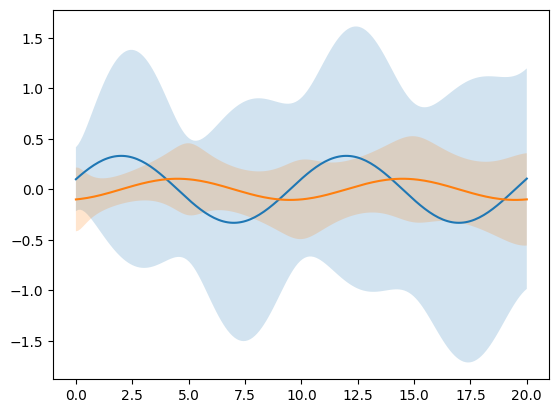

In [364]:
plt.plot(ts,mean[:,0])
plt.fill_between(ts, mean[:,0] - std[:,0,0], states.mean[:,0] + std[:,0,0], alpha=0.2)

plt.plot(ts,mean[:,1])
plt.fill_between(ts, states.mean[:,1] - std[:,1,1], states.mean[:,1] + std[:,1,1], alpha=0.2)

In [292]:
from probjax.inference.filtering.uncented_kalman_filter import ukf, merwe_sigma_point, unscented_transform

In [329]:
# Jax 64 bit precision

from jax.config import config
config.update("jax_enable_x64", True)

/tmp/ipykernel_10394/3750078076.py:3: DeprecationWarning: Accessing jax.config via the jax.config submodule is deprecated.
  from jax.config import config


In [330]:
def transition_fn(x, t_old, t):
    return jnp.dot(A, x)

def observation_fn(x, t):
    return jnp.dot(C, x)


In [331]:
kernel = ukf(transition_fn, B*0, observation_fn, D)

In [335]:
mu0 = mu0.astype(jnp.float64)
C0 = C0.astype(jnp.float64)

In [336]:
state = kernel.init(mu0, C0, 0.)

In [337]:
ts = jnp.linspace(0, 20, 200)
states, info = filter(jax.random.PRNGKey(0), ts, jnp.array([100.]), jnp.array([0.,0.]), kernel, mu0, C0)

In [338]:
mean = states.mean
cov = states.cov
std = jax.vmap(jnp.linalg.cholesky)(cov)

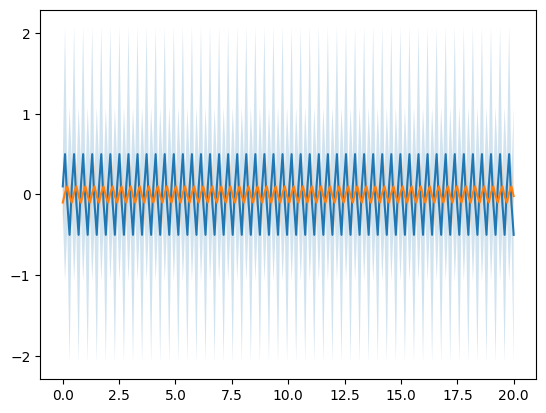

In [340]:
plt.plot(ts,mean[:,0])
plt.fill_between(ts, mean[:,0] - std[:,0,0], states.mean[:,0] + std[:,0,0], alpha=0.2)

plt.plot(ts,mean[:,1])
plt.fill_between(ts, states.mean[:,1] - std[:,1,1], states.mean[:,1] + std[:,1,1], alpha=0.2)